## Atmospheric Carbon Dioxide from Mauna Loa

NOAA Global Monitoring Laboratory Atmospheric Carbon Dioxide trend data from the Mauna Loa Observatory.

Source: [gml.noaa.gov/ccgg/trends/mlo.html](https://gml.noaa.gov/ccgg/trends/mlo.html). For the CSV files,
see [Trends in Atmospheric Carbon Dioxide data](https://gml.noaa.gov/ccgg/trends/data.html).

NOTE: As of 2021 Feb 10 NOAA CO2 data is posted on the WMO X2019 scale. 

Citation: Dr. Pieter Tans, NOAA/GML (gml.noaa.gov/ccgg/trends/) and Dr. Ralph Keeling, Scripps Institution of
Oceanography (scrippsco2.ucsd.edu/).

This notebook will look for the monthly CO<sub>2</sub> data from NOAA, and if missing or more than 1 day old, it
will download the latest data from the NOAA website.  This can fail, requiring you to retrieve the data by hand,
or `touch` and older file to suppress download.

In [54]:
%matplotlib inline

import os, time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [55]:
aspect = 1.5 # 4.0/3.0 

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 7
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
axisFontSize = np.rint(axisFontSize/scaleFac)
labelFontSize = np.rint(labelFontSize/scaleFac)

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## NOAA MLO Data

Monthly data beginning in March 1958 through the latest update.

Source data in file `co2_mm_mlo.csv` which has many columns. We plot
 * `decimal date` - year+month in decimal form
 * `average` = monthly averaged CO2 in ppm
 * `interpolated` = interpolated trend line in ppm

### Retrieve the latest CO<sub>2</sub> data from NOAA

See if there is a file named 'co2_mm_mlo.csv' in the current working directory.  If none or more than 1 day old,
try to download it from the NOAA GML website to update it.

You can force update by setting `updateFile = True`

In [56]:
dataURL = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv'
co2File = 'co2_mm_mlo.csv'
updateFile = False

oldFile = False
if not os.path.exists(co2File):
    updateFile = True
    oldFile = False
else:
    oldFile = True
    fileAge = (time.time() - os.path.getmtime(co2File))/86400.0
    if fileAge >= 1.0:
        updateFile = True
        
if updateFile:
    try:
        with urllib.request.urlopen(dataURL) as wf:
            raw = wf.read().decode('utf-8')
    except:
        if oldFile:
            print('Problem retrieving updated data, using old file')
        else:
            print('Problem retrieving updated data, no old file to use')
            print('Try retrieving by hand and re-run')
    if oldFile:
        os.remove(co2File)
    f = open(co2File,'w')
    f.write(raw)
    f.close()   
    print('Retrieved updated CO2 data from NOAA')
else:
    print('CO2 data from NOAA are up-to-date (<1d old)')

CO2 data from NOAA are up-to-date (<1d old)


### Read the data file

Data are in CSV format. 

The `average` column is the monthly value which shows a sinusoidal pattern due to seasonal uptake and release of
CO2 by vegetation. 

The `deseasonalized` column shows the general trend in CO2 concentration with the seasonal component subtracted. Note that older data from this website used `interpolated` instead of `deseasonalized` for that data.

In [57]:
title = r'Atmospheric CO$_2$ at Mauna Loa Observatory'
source = 'Scripps Institution of Oceanography\nNOAA Global Monitoring Laboratory'
srcURL = 'https://gml.noaa.gov/ccgg/trends/mlo.html'

data = pd.read_csv(co2File,comment='#')
year = np.array(data['year'])
month = np.array(data['month'])
date = np.array(data['decimal date'])
co2ppm = np.array(data['average'])  # monthly average CO2 in ppm
trend = np.array(data['deseasonalized']) # interpolated trendline

# find the maximum CO2 concentration and date

monthNames = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

co2Max = np.max(co2ppm)
idx = np.argmax(co2ppm)
maxDate = f'{monthNames[month[idx]-1]} {year[idx]}'
maxCO2 = f'Maximum CO$_2$ concentration\n {co2Max:.0f}ppm measured {maxDate}'

print(f'Maximum CO2 concentration is {co2Max:.2f} ppm measured in {maxDate}')

plotFile = f'NOAA_AtmosCO2_MLO_{year[-1]}.png' 

Maximum CO2 concentration is 428.15 ppm measured in Mar 2025


### Make the plot

Plot monthly average CO2 in ppm vs time.

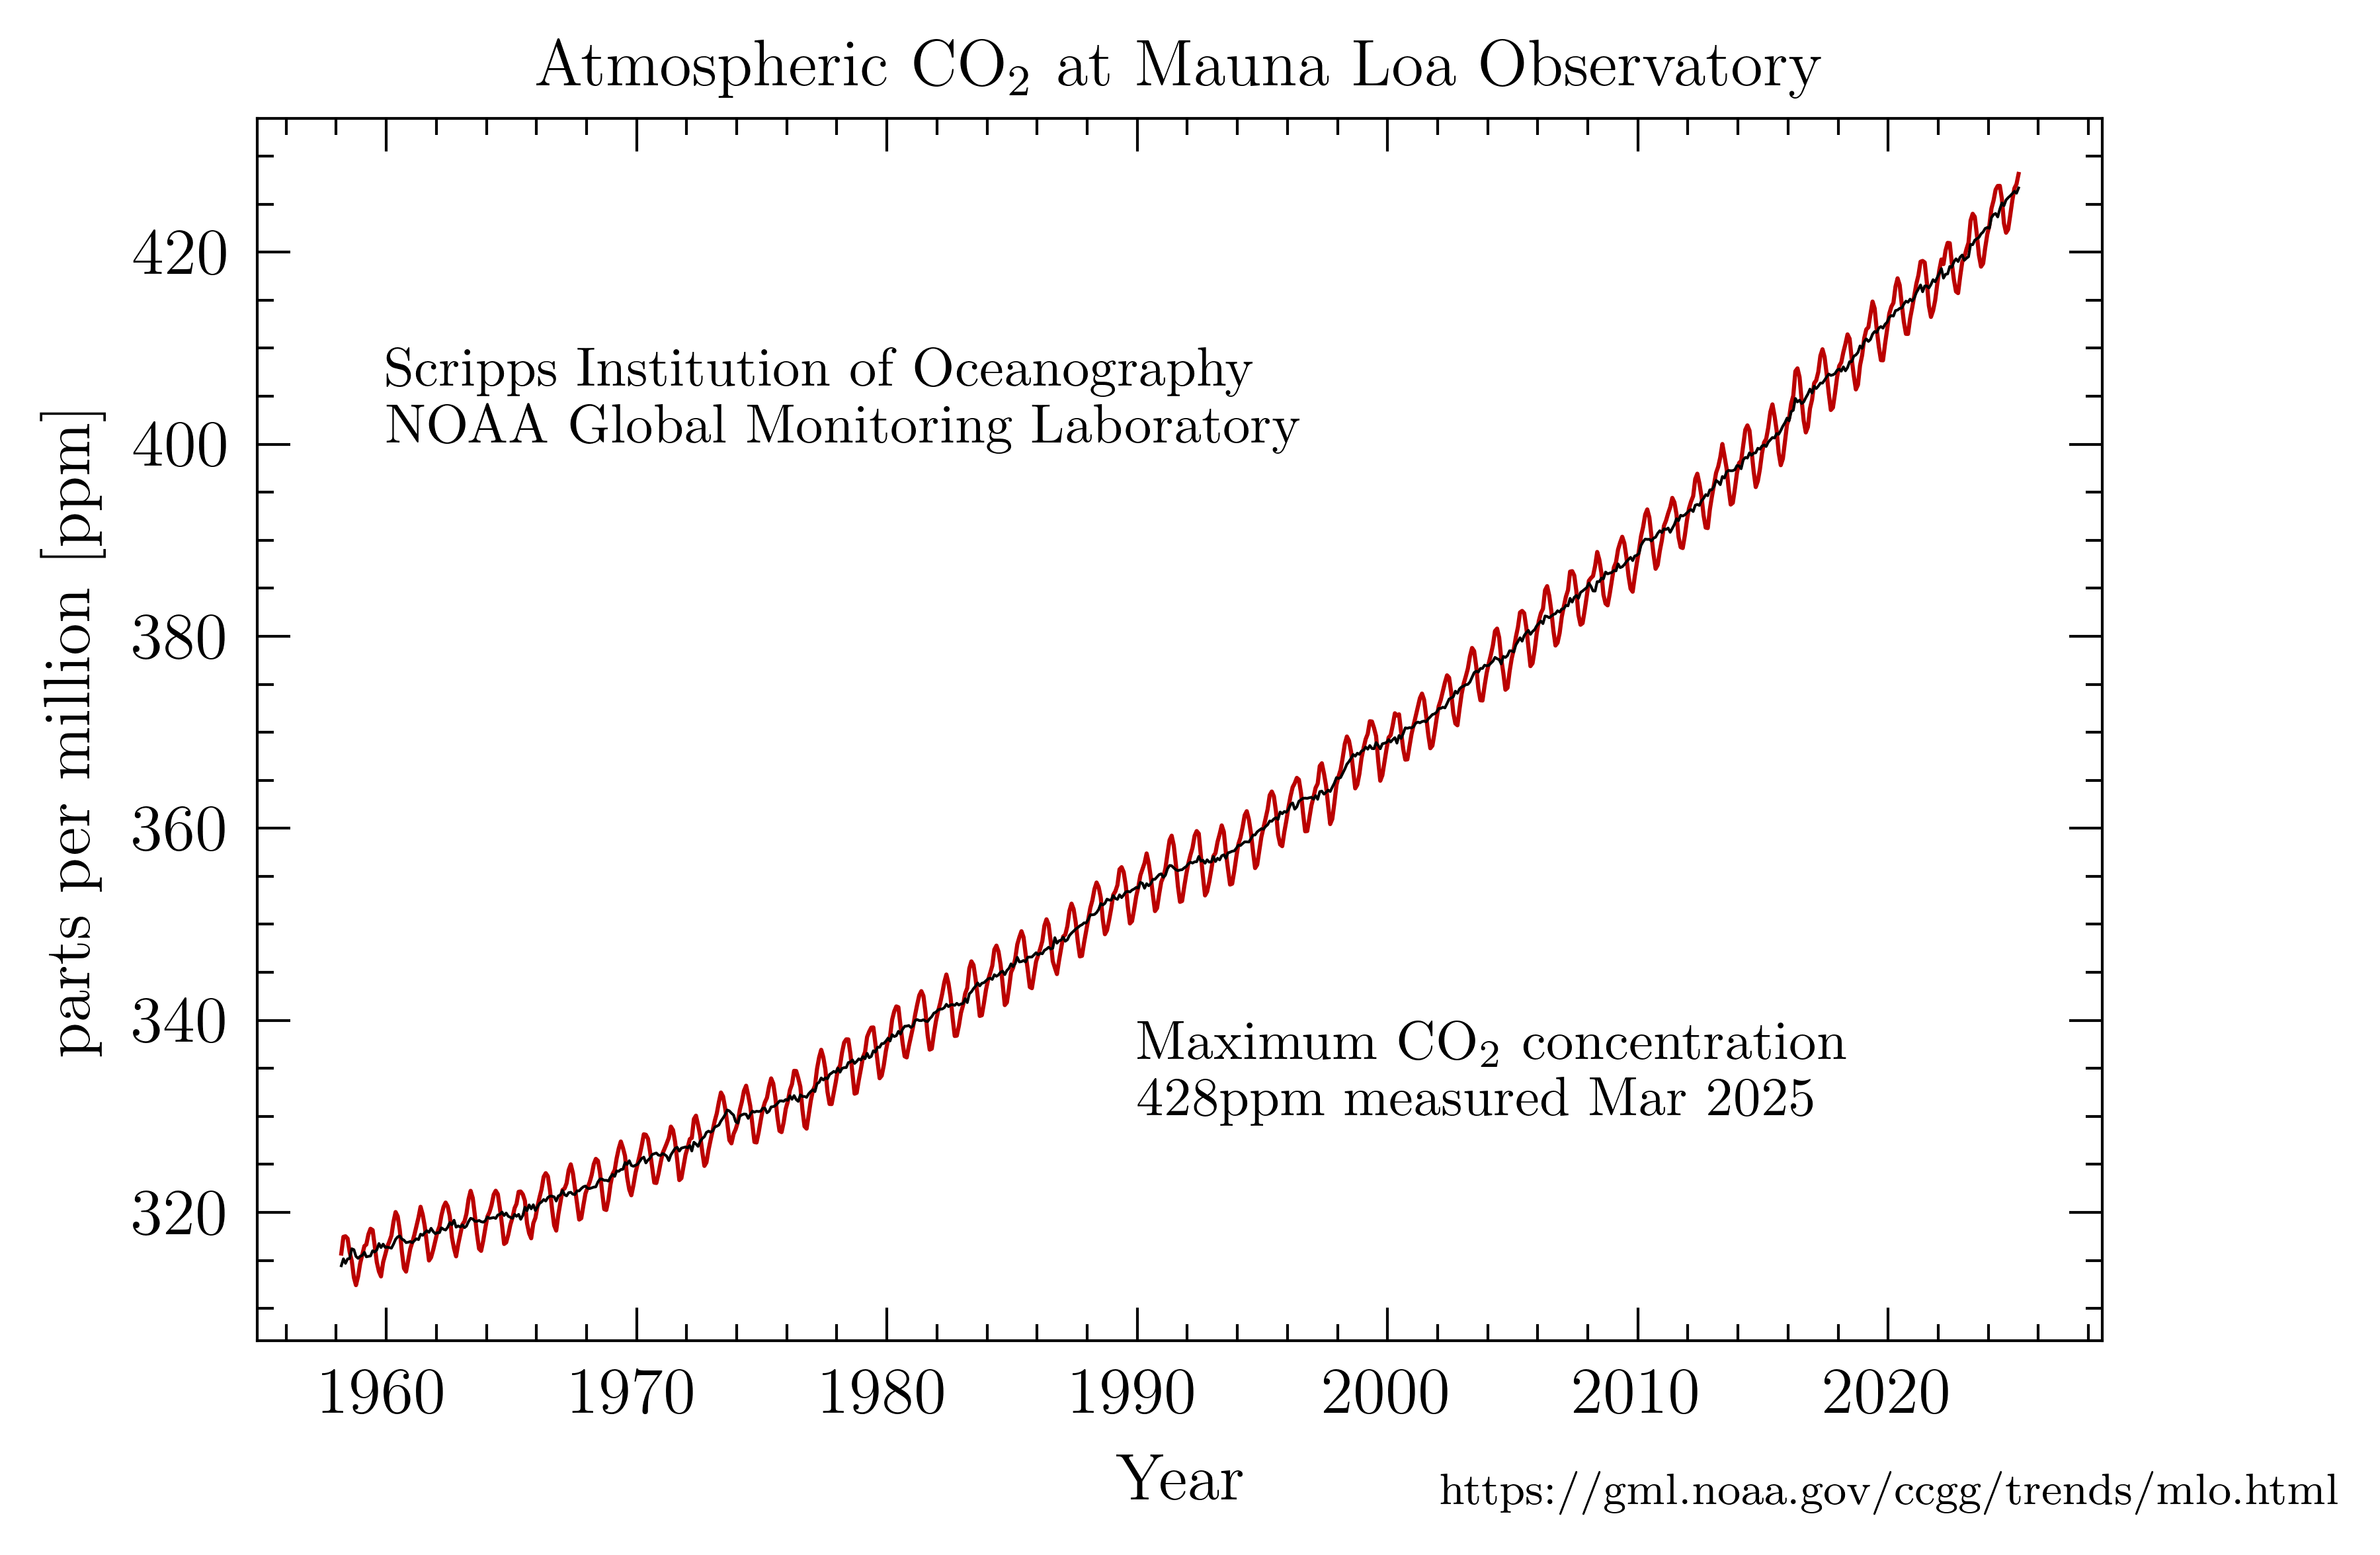

In [58]:
fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

dt = np.max(date)-np.min(date)
yrMin = np.min(date) - 0.05*dt
yrMax = np.max(date) + 0.05*dt

dppm = np.max(co2ppm)-np.min(co2ppm)
co2Min = np.min(co2ppm) - 0.05*dppm
co2Max = np.max(co2ppm) + 0.05*dppm

plt.xlim(yrMin,yrMax)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(2))
plt.xlabel(r'Year',fontsize=axisFontSize)

plt.ylim(co2Min,co2Max)
ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(5))
plt.ylabel(r'parts per million [ppm]',fontsize=axisFontSize)

plt.plot(date,co2ppm,ls='-',color='#bb0000',lw=0.75,zorder=10)
plt.plot(date,trend,ls='-',color='black',lw=0.5,zorder=10)
plt.title(title,fontsize=axisFontSize)

# Data Source

plt.text(1960,410,source,va='top',ha='left',fontsize=10)
plt.text(1.0,0.0,srcURL,fontsize=8,ha='right',va='bottom',transform=plt.gcf().transFigure)

# Maximum CO2 concentration

plt.text(1990,340,maxCO2,va='top',ha='left',fontsize=10)

# Make the plot

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()